# Session 1B — Spatial context

Build spatial and molecular neighborhoods, inspect feature maps, and explore modality structure.

Work through the parts in order. Each part ends by writing its existing JSON checkpoint,
so the consolidation changes file organization without removing pause/resume milestones.


In [1]:
from pathlib import Path
import sys

# Locates the cloned tutorial in Google Colab after Session 0 setup.
candidates = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
colab_root = Path("/content/ECCB-2026-Tutorial/hands-on_tutorial")
if colab_root.is_dir():
    candidates.insert(0, colab_root.resolve())

for candidate in candidates:
    if (candidate / "src" / "dgat_tutorial").is_dir():
        tutorial_root = candidate
        break
else:
    raise FileNotFoundError(
        "Could not find hands-on_tutorial/. In Colab, run notebooks/session_00/00_colab_setup.ipynb first."
    )

sys.path.insert(0, str(tutorial_root / "src"))

from dgat_tutorial.checkpoints import tutorial_paths, write_checkpoint

paths = tutorial_paths(tutorial_root)
print(f"Tutorial root: {paths.root}")


Tutorial root: /Users/zmengaf/Documents/ECCB tuto/hands-on_tutorial


## Session 1 · Part 3 — Spatial neighborhoods and exploratory structure

**Goal:** construct the **official DGAT graphs** and inspect exploratory structure.

Official DGAT (`utils/Graph_utils.py`) builds:

1. a **spatial 6-NN** graph
2. an **RNA molecular 10-NN** graph in PCA space (when >1500 genes; 85% variance)
3. a **protein molecular 10-NN** graph in feature space

The RNA encoder uses `spatial ∪ RNA-molecular` edges; the protein encoder uses
`spatial ∪ protein-molecular` edges. This notebook visualizes the **spatial component
only** for readability, then saves the **union** graphs that the encoders actually use.


### 1. Reload and process the data independently


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from dgat_tutorial.data import load_tutorial_data
from dgat_tutorial.plotting import plot_spatial_feature, plot_spatial_knn_graph
from dgat_tutorial.processing import build_dgat_graphs, knn_edge_index, process_modalities_official_dgat

dataset = load_tutorial_data(paths.raw_data)
processed = process_modalities_official_dgat(
    dataset.spots,
    dataset.transcripts,
    dataset.proteins,
    dgat_repo_dir=paths.root / "external" / "DGAT",
)
spots = processed.spots
rna = processed.normalized_transcripts
protein = processed.normalized_proteins
graphs = build_dgat_graphs(spots, rna, protein)
edge_index = graphs["spatial_edge_index"]
print(
    f"Spatial 6-NN edges: {graphs['spatial_edge_index'].shape[1]}; "
    f"RNA union graph: {graphs['rna_edge_index'].shape[1]}; "
    f"protein union graph: {graphs['protein_edge_index'].shape[1]}"
)


/Users/zmengaf/miniconda3/envs/eccb-dgat-tutorial/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/Users/zmengaf/miniconda3/envs/eccb-dgat-tutorial/lib/python3.10/site-packages/muon/_core/preproc.py:31: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  if Version(scanpy.__version__) < Version("1.10"):


/Users/zmengaf/Documents/ECCB tuto/hands-on_tutorial/external/DGAT/utils/Preprocessing.py:51: ImplicitModificationWarning: Setting element `.layers['raw']` of view, initializing view as actual.
  adata.layers['raw'] = adata.X.copy()


/Users/zmengaf/Documents/ECCB tuto/hands-on_tutorial/external/DGAT/utils/Preprocessing.py:52: ImplicitModificationWarning: Setting element `.layers['raw']` of view, initializing view as actual.
  pdata.layers['raw'] = pdata.X.copy()


Spatial 6-NN edges: 25146; RNA union graph: 62477; protein union graph: 56469


#### Figure 3 — Spatial neighborhood structure (one component of the encoder graph)

Drawing every edge on all ~4,000 spots makes the local neighborhood structure
unreadable, so this figure splits overview and zoom for the **spatial 6-NN**
component only. Remember: each DGAT encoder also unions a molecular 10-NN graph.

- **Left:** all spots as nodes (no edges), with a red box marking the corner region.
- **Right:** undirected spatial 6-nearest-neighbor edges inside that corner.
- **Highlight:** the red spot is a boundary example; the orange spots are its spatial
  neighbors in this teaching view. The full encoder edge set is larger once molecular
  neighbors are unioned (saved below as `rna_edge_index` / `protein_edge_index`).


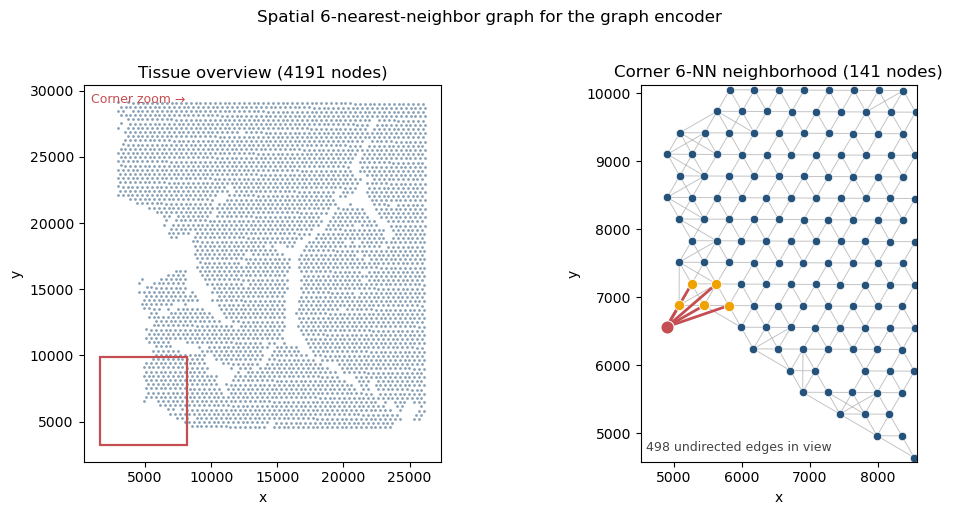

In [3]:
fig, _ = plot_spatial_knn_graph(spots, edge_index, n_neighbors=6, zoom_corner="lower_left")
graph_path = paths.figures / "session01_spatial_knn_graph.png"
fig.savefig(graph_path, dpi=160, bbox_inches="tight")
plt.show()


#### Figure 4 — Normalized RNA and protein landscapes


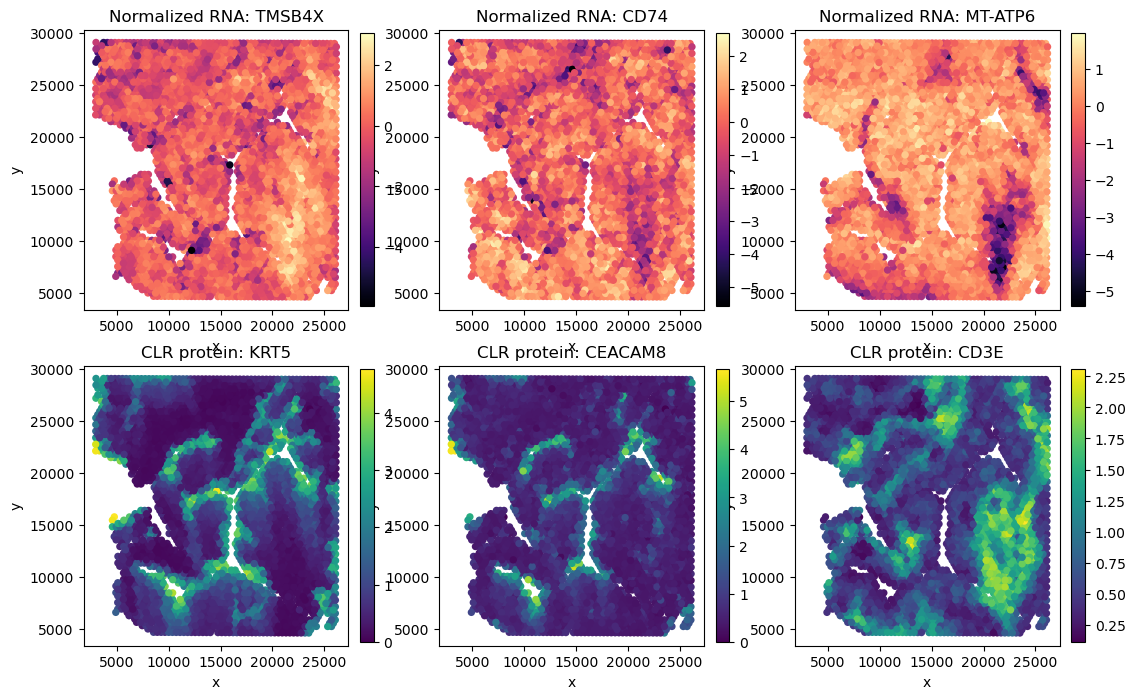

In [4]:
rna_features = rna.var(axis=0).nlargest(3).index
protein_features = protein.var(axis=0).nlargest(3).index
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
for ax, feature in zip(axes[0], rna_features):
    plot_spatial_feature(spots, rna[feature], f"Normalized RNA: {feature}", cmap="magma", ax=ax)
for ax, feature in zip(axes[1], protein_features):
    plot_spatial_feature(spots, protein[feature], f"CLR protein: {feature}", cmap="viridis", ax=ax)
figure_path = paths.figures / "session01_normalized_spatial_features.png"
fig.savefig(figure_path, dpi=160, bbox_inches="tight")
plt.show()


#### Figure 5 — Exploratory RNA and protein embeddings

Colors are exploratory KMeans groups in PCA space (**not** curated cell-type labels).

- **Left:** RNA PCA; spots share one of four RNA cluster colors (`0`–`3`).
- **Middle:** protein PCA with its **own** four protein clusters (same palette, independent IDs).
- **Right:** the RNA cluster colors from the left panel mapped back onto tissue coordinates.

Use these panels only to check whether modality structure and spatial organization look coherent before moving to DGAT.


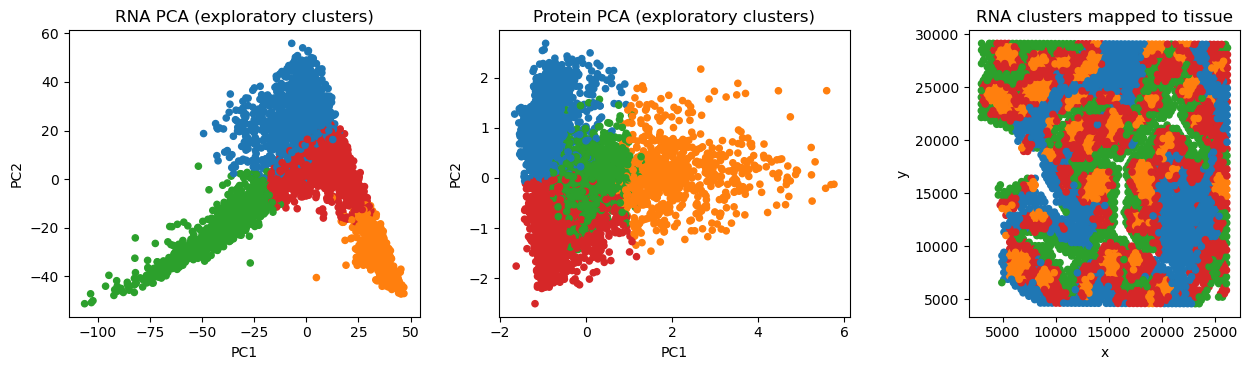

In [5]:
def pca_clusters(matrix, n_clusters=4, n_pcs=20):
    n_pcs = min(n_pcs, matrix.shape[0] - 1, matrix.shape[1])
    pcs = PCA(n_components=n_pcs, random_state=7).fit_transform(matrix)
    clusters = KMeans(n_clusters=min(n_clusters, len(matrix)), n_init=20, random_state=7).fit_predict(pcs)
    return pcs[:, :2], clusters  # visualize PC1/PC2; cluster in higher-D PC space


def cluster_colors(labels, cmap_name="tab10"):
    """Map integer cluster IDs to stable discrete colors."""
    cmap = plt.get_cmap(cmap_name)
    return np.asarray([cmap(int(label) % 10) for label in labels])


rna_pca, rna_cluster = pca_clusters(rna)
protein_pca, protein_cluster = pca_clusters(protein)
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
axes[0].scatter(rna_pca[:, 0], rna_pca[:, 1], c=cluster_colors(rna_cluster), s=20)
axes[0].set_title("RNA PCA (exploratory clusters)")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

axes[1].scatter(protein_pca[:, 0], protein_pca[:, 1], c=cluster_colors(protein_cluster), s=20)
axes[1].set_title("Protein PCA (exploratory clusters)")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")

axes[2].scatter(spots["x"], spots["y"], c=cluster_colors(rna_cluster), s=20)
axes[2].set_title("RNA clusters mapped to tissue")
axes[2].set_xlabel("x")
axes[2].set_ylabel("y")
axes[2].set_aspect("equal")

embedding_path = paths.figures / "session01_modality_pca_and_spatial_clusters.png"
fig.tight_layout()
fig.savefig(embedding_path, dpi=160, bbox_inches="tight")
plt.show()


### Save the graph and checkpoint


In [6]:
edge_table = pd.DataFrame({"source": spots.index[edge_index[0]], "target": spots.index[edge_index[1]]})
edge_path = paths.results / "session01_spatial_knn_edges.csv"
edge_table.to_csv(edge_path, index=False)
manifest = write_checkpoint(
    "1.3", [edge_path, graph_path, figure_path, embedding_path],
    summary={"nodes": len(spots), "directed_edges": edge_index.shape[1]}, start=paths.root,
)
print(f"Checkpoint written: {manifest}")


Checkpoint written: /Users/zmengaf/Documents/ECCB tuto/hands-on_tutorial/checkpoints/session_01/part_1_3.json


### Check

Trace one spot from its normalized feature vector to its node and six outgoing spatial edges. DGAT's
graph attention layers learn how much neighbor information to aggregate; the graph defines which
neighbors are available.
